# standard codes

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import requests
import os
import time
from google.colab import userdata
from google.colab import drive
drive.mount('/content/drive')
import json
import glob
from IPython.display import clear_output
import cv2
from scipy import signal
import scipy.spatial.distance as cdist

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
tng_api_key = userdata.get('TNG_API_KEY')
baseUrl = 'http://www.tng-project.org/api/'
headers = {"api-key":tng_api_key}

In [3]:
def get(path, params=None, out_filename=None):
    headers = {"api-key":tng_api_key}
    r = requests.get(path, params=params, headers=headers)
    r.raise_for_status()

    if out_filename is not None:
        with open(out_filename, 'wb') as f:
            f.write(r.content)
        return out_filename

    if r.headers['content-type'] == 'application/json':
        return r.json()

    if 'content-disposition' in r.headers:
        filename = r.headers['content-disposition'].split("filename=")[1]
        with open(filename, 'wb') as f:
            f.write(r.content)
        return filename

    return r

In [5]:
r = get(baseUrl)

for simulation in r['simulations']: #only get TNG50
    if simulation['name'] == 'TNG50-1':
        url = simulation['url']
        break

tng50 = get(url)

url = 'http://www.tng-project.org/api/TNG50-1/snapshots/z=1.8/'
snapshot = get(url)

sub_url = f"http://www.tng-project.org/api/TNG50-1/snapshots/{snapshot['number']}/subhalos/0/"
subhalo = get(sub_url)

#new codes

In [40]:
vis_url1 = sub_url + "vis.png?partField=bfield_x&min=-6000&max=7500&rVirFracs=-1.0"
f1= get(vis_url1, out_filename="mag x")

img1 = cv2.imread(f1)
img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
cbar1 = img1_rgb[100:-100, 1220:-140]

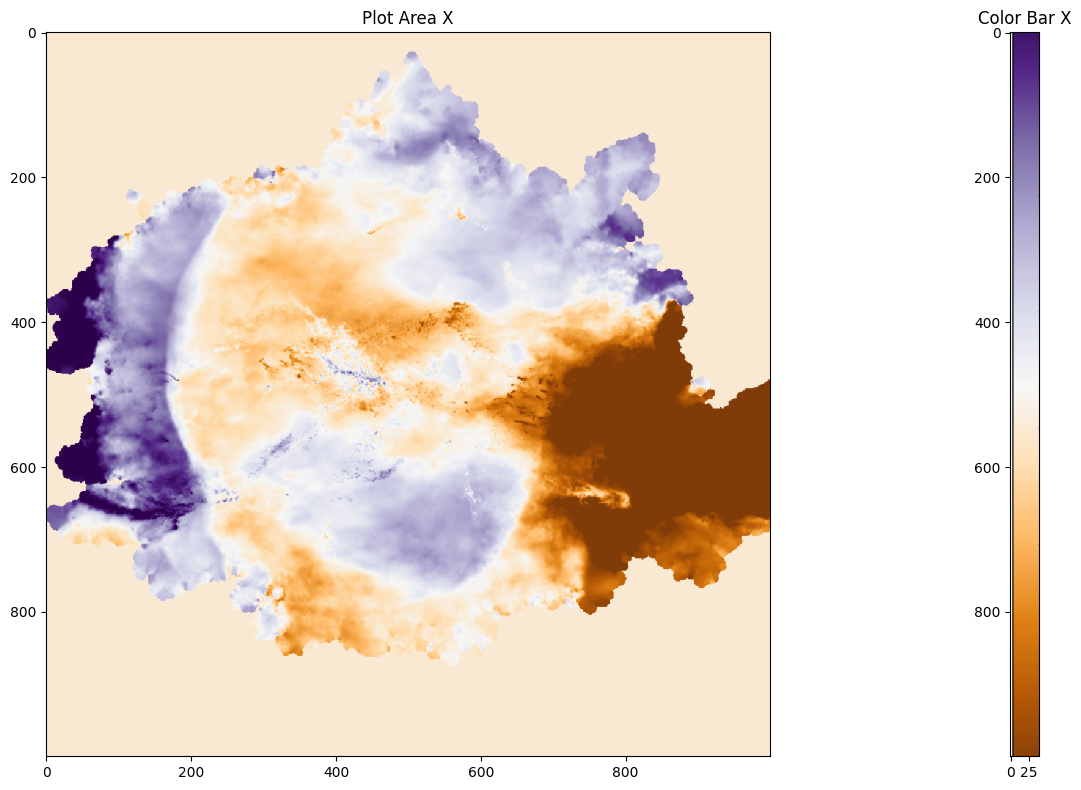

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
area1 = img1_rgb[100:-100, 200:1200]

axes[1].imshow(cbar1)
axes[1].set_title('Color Bar X')
axes[0].imshow(area1)
axes[0].set_title('Plot Area X')

plt.tight_layout()
plt.show()

In [42]:
vis_url2 = sub_url + "vis.png?partField=bfield_y&min=-6000&max=7500&rVirFracs=-1.0"
f2= get(vis_url1, out_filename="mag y")

img2 = cv2.imread(f2)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
cbar2 = img2_rgb[100:-100, 1220:-140]

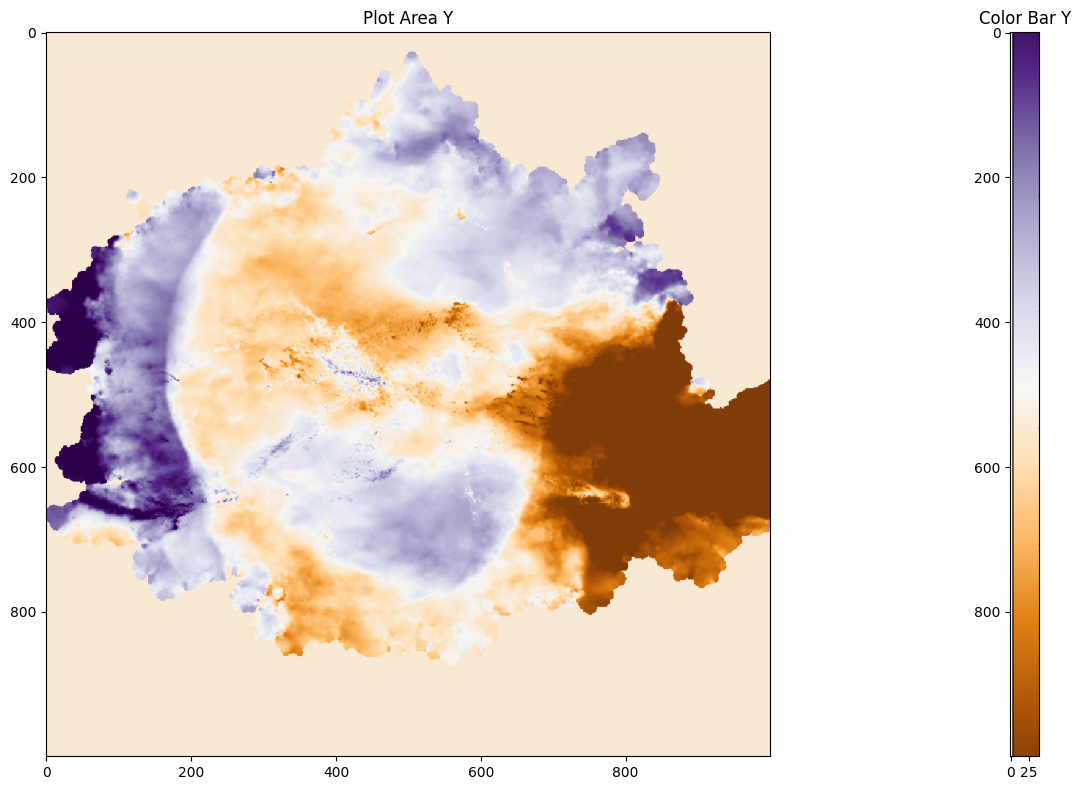

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
area2 = img2_rgb[100:-100, 200:1200]

axes[1].imshow(cbar2)
axes[1].set_title('Color Bar Y')
axes[0].imshow(area2)
axes[0].set_title('Plot Area Y')

plt.tight_layout()
plt.show()

In [46]:
vis_url3 = sub_url + "vis.png?partField=bfield_z&min=-6000&max=7500&rVirFracs=-1.0"
f3= get(vis_url3, out_filename="mag z")

img3 = cv2.imread(f3)
img3_rgb = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)
cbar3 = img3_rgb[100:-100, 1220:-140]

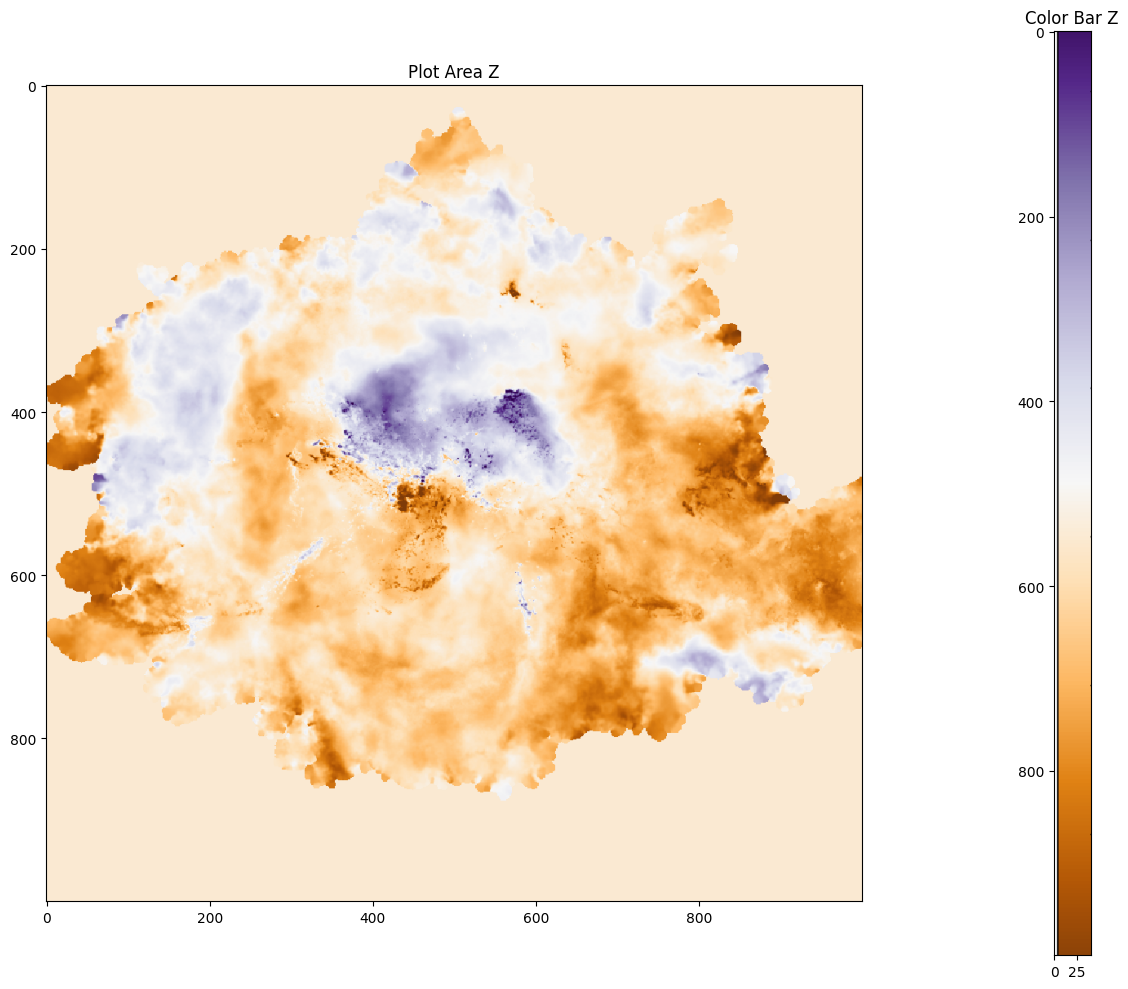

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10))
area3 = img3_rgb[100:-100, 200:1200]

axes[1].imshow(cbar3)
axes[1].set_title('Color Bar Z')
axes[0].imshow(area3)
axes[0].set_title('Plot Area Z')

plt.tight_layout()
plt.show()

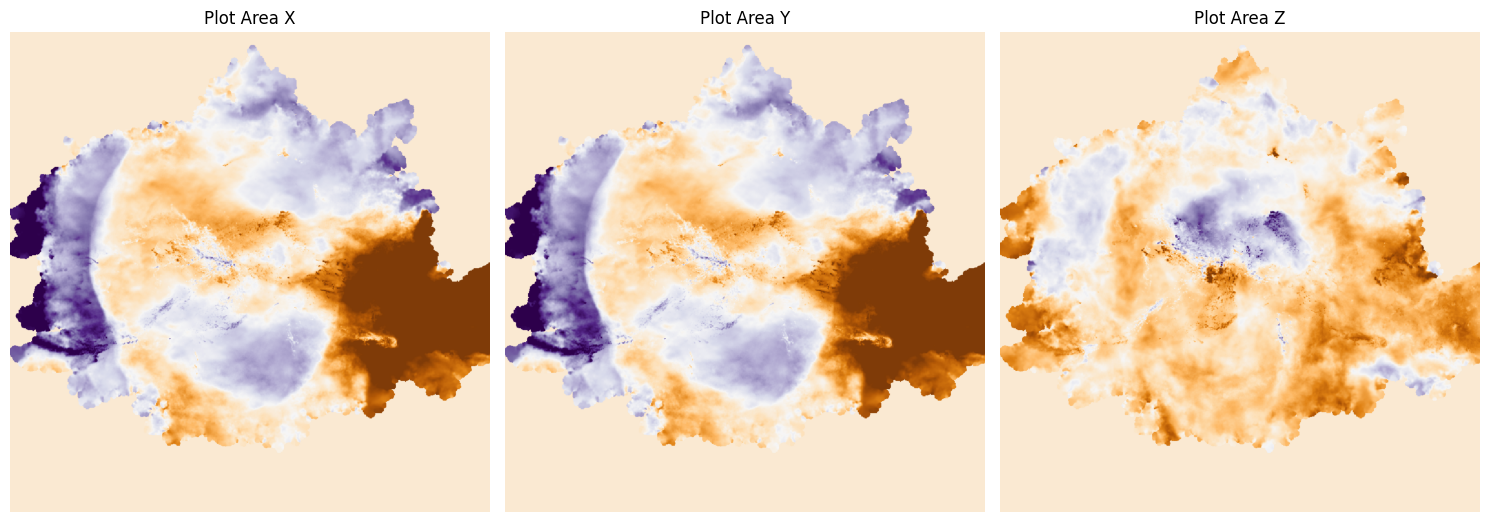

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(15, 8))

axes[0].imshow(area1)
axes[0].set_title('Plot Area X')
axes[0].axis('off')

axes[1].imshow(area2)
axes[1].set_title('Plot Area Y')
axes[1].axis('off')

axes[2].imshow(area3)
axes[2].set_title('Plot Area Z')
axes[2].axis('off')

plt.tight_layout()
plt.show()